In [1]:
import sys; sys.path.append('/home/ferjao_k/aare/build')

from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import boost_histogram as bh
import time

from aare import File, ClusterFinder, ClusterFinderMT, ClusterCollector, ClusterFinderCUDA

In [2]:
def make_hist(clusters):
    h = bh.Histogram(bh.axis.Regular(100, -2, 4000))
    h.fill(clusters.sum())
    return h

In [3]:
base = Path('/mnt/sls_det_storage/matterhorn_data/aare_test_data/')
f = File(base / 'Moench03new/cu_half_speed_master_4.json')

n_frames_pd = 1000
N           = 40000
cluster_size = (3, 3)
image_size   = (f.rows, f.cols)
capacity     = 100_000 #3_000_000

print(f'Image size:       {image_size}')
print(f'Pedestal frames:  {n_frames_pd}')
print(f'Data frames:      {N}')

Image size:       (400, 400)
Pedestal frames:  1000
Data frames:      40000


## Pedestal (both finders trained on identical frames)

- Modify the boolean `SERIAL` to choose between the sequential CPU version (ClusterFinder) and its multi-threaded homologue (ClusterFinderMT)

In [4]:
SERIAL = True

In [5]:
if(SERIAL):
    cf_cpu  = ClusterFinder(image_size, cluster_size, capacity=capacity)
else:
    cf_cpu  = ClusterFinderMT(image_size, cluster_size, capacity=capacity, n_threads=24)
    sink = ClusterCollector(cf_cpu)

In [6]:
N_STREAMS  = 10
cf_cuda = ClusterFinderCUDA(image_size, cluster_size, capacity=capacity, n_streams=N_STREAMS)

In [7]:
t0 = time.perf_counter()
for _ in range(n_frames_pd):
    img = f.read_frame()
    cf_cpu.push_pedestal_frame(img.copy())
    cf_cuda.push_pedestal_frame(img.copy())
print(f'Pedestal ({n_frames_pd} frames): {time.perf_counter() - t0:.3f}s')

Pedestal (1000 frames): 0.480s


## Read all data frames into memory (I/O out of the timing loop)

In [8]:
f.seek(n_frames_pd)
t0 = time.perf_counter()
data = f.read_n(N)
t_io = time.perf_counter() - t0
print(f'Reading {N} frames:        {t_io:.3f}s  ({N/t_io:.0f} FPS, '
      f'{f.bytes_per_frame * N / 1024**2 / t_io:.3f} GB/s)')

Reading 40000 frames:        1.922s  (20815 FPS, 6352.256 GB/s)


## CPU clustering

In [9]:
t0 = time.perf_counter()
for frame in data:
    cf_cpu.find_clusters(frame)
t_cpu = time.perf_counter() - t0

if(SERIAL):
    clusters_cpu = cf_cpu.steal_clusters(realloc_same_capacity=False)
    n_clusters_cpu = clusters_cpu.size
    
    hist_cpu  = make_hist(clusters_cpu)
else:
    cf_cpu.stop()
    sink.stop()
    
    clusters_cpu = sink.steal_clusters() #cf_cpu.steal_clusters(realloc_same_capacity=False)
    
    hist_cpu = bh.Histogram(bh.axis.Regular(100, -2, 4000))
    n_clusters_cpu = 0
    for cv in clusters_cpu:
        hist_cpu.fill(cv.sum())
        n_clusters_cpu += cv.size
        
print(f'CPU clustering:          {t_cpu:.3f}s ({N/t_cpu:.0f} FPS, '
      f'{n_clusters_cpu} clusters, {n_clusters_cpu/N:.2f}/frame)')

CPU clustering:          73.207s (546 FPS, 55449596 clusters, 1386.24/frame)


## CUDA clustering

In [10]:
# # Warmup: first kernel launch pays CUDA context + pedestal H2D upload cost
# cf_cuda.find_clusters(data[0])
# _ = cf_cuda.steal_clusters(realloc_same_capacity=False)

# t0 = time.perf_counter()
# for frame in data:
#     cf_cuda.find_clusters(frame)
# t_cuda = time.perf_counter() - t0
# clusters_cuda = cf_cuda.steal_clusters(realloc_same_capacity=False)
# n_clusters_cuda = clusters_cuda.size
# print(f'CUDA clustering:          {t_cuda:.3f}s  ({N/t_cuda:.0f} FPS, '
#       f'{n_clusters_cuda} clusters, {n_clusters_cuda/N:.2f}/frame)')
# print(f'Speedup (CPU / CUDA):     {t_cpu / t_cuda:.2f}×')

# hist_cuda = make_hist(clusters_cuda)

In [11]:
BATCH_SIZE = 2000

# warmup
_ = cf_cuda.find_clusters_batched(data[0:BATCH_SIZE], first_frame=0)

t0 = time.perf_counter()
clusters_cuda_per_frame = []
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_cuda_per_frame.extend(
        cf_cuda.find_clusters_batched(data[start:stop], first_frame=start)
    )
t_cuda = time.perf_counter() - t0

n_clusters_cuda = sum(cv.size for cv in clusters_cuda_per_frame)

print(f'CUDA clustering:          {t_cuda:.3f}s  ({N/t_cuda:.0f} FPS, '
      f'{n_clusters_cuda} clusters, {n_clusters_cuda/N:.2f}/frame)')
print(f'Speedup (CPU / CUDA):     {t_cpu / t_cuda:.2f}×')

CUDA clustering:          2.385s  (16774 FPS, 55081141 clusters, 1377.03/frame)
Speedup (CPU / CUDA):     30.70×


In [12]:
def make_hist_from_batch(result_list):
    h = bh.Histogram(bh.axis.Regular(100, -2, 4000))
    energies = [np.asarray(cv.sum()).ravel() for cv in result_list if cv.size > 0]
    if energies:
        h.fill(np.concatenate(energies))
    return h

hist_cuda = make_hist_from_batch(clusters_cuda_per_frame)

## Agreement check: 
- Cluster counts should match closely.
- However, as the CUDA CF updates the pedestal once per frame rather than per-pixel, a small divergence after the first few frames is expected.

In [13]:
diff = abs(n_clusters_cpu - n_clusters_cuda)
rel  = diff / max(n_clusters_cpu, 1)
print(f'Cluster count diff:       {diff} ({rel:.2%})')

Cluster count diff:       368455 (0.66%)


## Plots

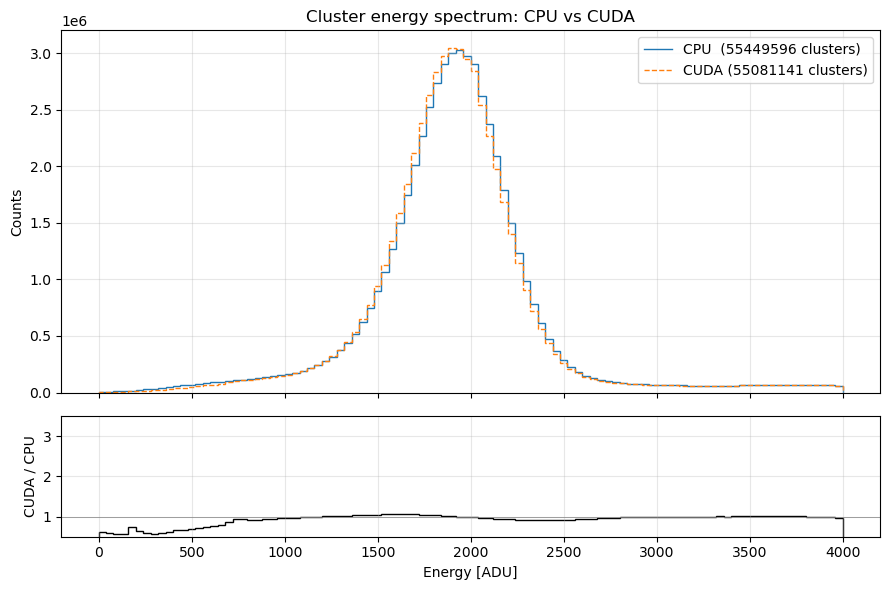

In [14]:
fig, (ax_spec, ax_ratio) = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

edges = hist_cpu.axes[0].edges
cpu_vals = hist_cpu.values()
cuda_vals = hist_cuda.values()

ax_spec.stairs(cpu_vals, edges, label=f'CPU  ({n_clusters_cpu} clusters)')
ax_spec.stairs(cuda_vals, edges, label=f'CUDA ({n_clusters_cuda} clusters)', linestyle='--')
ax_spec.set_ylabel('Counts')
ax_spec.set_title('Cluster energy spectrum: CPU vs CUDA')
ax_spec.legend()
ax_spec.grid(alpha=0.3)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(cpu_vals > 0, cuda_vals / cpu_vals, np.nan)

ax_ratio.stairs(ratio, edges, color='k')
ax_ratio.axhline(1.0, color='gray', linewidth=0.5)
ax_ratio.set_ylabel('CUDA / CPU')
ax_ratio.set_xlabel('Energy [ADU]')
ax_ratio.set_ylim(0.5, 3.5)
ax_ratio.grid(alpha=0.3)

plt.tight_layout()
plt.show()